In [1]:
import torch
import sys
sys.path.append("")
sys.path.append("..")
sys.path.append("../kronfluence")

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of CUDA devices: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
        print(f"  Compute capability: {torch.cuda.get_device_properties(i).major}.{torch.cuda.get_device_properties(i).minor}")
    print(f"Current device: {torch.cuda.current_device()}")
else:
    print("No CUDA devices available")

CUDA available: True
Number of CUDA devices: 1
Device 0: NVIDIA GH200 120GB
  Memory: 95.0 GB
  Compute capability: 9.0
Current device: 0


In [2]:
import argparse

parser = argparse.ArgumentParser(description="MNIST Influence Experiment")

# Random seed
parser.add_argument('--random_seed', type=int, default=12, help='Random seed') # 52, 12 is great

# Model parameters
parser.add_argument('--batch_size', type=int, default=512, help='Batch size for training')
parser.add_argument('--learning_rate', type=float, default=0.4, help='Learning rate')
parser.add_argument('--momentum', type=float, default=0.9, help='Momentum')
parser.add_argument('--weight_decay', type=float, default=0.001, help='Weight decay')
parser.add_argument('--epochs', type=int, default=30, help='Number of training epochs')

# Hessian parameters
parser.add_argument('--damping', type=float, default=1e-3, help='Damping factor for IHVP')

# PGD parameters
parser.add_argument('--top_k', type=int, default=32, help='Number of points to perturb')
parser.add_argument('--epsilon', type=float, default=0.5, help='L_∞ budget')
parser.add_argument('--alpha', type=float, default=0.001, help='Step size')
parser.add_argument('--n_steps', type=int, default=20, help='PGD iterations')


args, _ = parser.parse_known_args()

In [3]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(args.random_seed)
np.random.seed(args.random_seed)



print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
PyTorch version: 2.7.0+cu128


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.ToTensor()
])

full_train_ds = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_ds = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

# Create a validation split from the training set (e.g., 90% train, 10% val)
num_train = int(0.9 * len(full_train_ds))
num_valid = len(full_train_ds) - num_train
train_ds, valid_ds = random_split(full_train_ds, [num_train, num_valid], generator=torch.Generator().manual_seed(args.random_seed))

img, label = full_train_ds[2]
print(img.shape) # torch.Size([3, 32, 32])


from infusion.dataloader import get_dataloader

# Dataloaders
train_dl = get_dataloader(train_ds, args.batch_size)
test_dl = get_dataloader(test_ds, args.batch_size)
valid_dl = get_dataloader(valid_ds, args.batch_size)


torch.Size([3, 32, 32])


In [5]:
import os
from infusion.train import fit

# Grab dataset metadata for CIFAR10
in_channels = full_train_ds[0][0].shape[0]    # 3
img_size = full_train_ds[0][0].shape[1]       # 32 for CIFAR10
num_classes = len(full_train_ds.classes)       # 10

import torch
import torch.nn as nn

class SimpleLogReg(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        # x: [batch_size, channels, height, width]
        x = x.view(x.size(0), -1)  # flatten for any image shape
        return self.linear(x)

# A tiny ResNet-like network with a couple of residual blocks for CIFAR/MNIST
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

class TinyResNet(nn.Module):
    def __init__(self, input_channels, num_classes):
        super().__init__()
        self.conv = nn.Conv2d(input_channels, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(inplace=True)

        # First residual block
        self.layer1 = ResidualBlock(32, 32)
        # Down + increase channels
        self.layer2 = ResidualBlock(32, 64, stride=2, downsample=nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=1, stride=2, bias=False),
            nn.BatchNorm2d(64)
        ))
        # Another downsampling block
        self.layer3 = ResidualBlock(64, 128, stride=2, downsample=nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=1, stride=2, bias=False),
            nn.BatchNorm2d(128)
        ))

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x



# For CIFAR10, input_dim is 3*32*32 = 3072
input_dim = in_channels * img_size * img_size


def make_model():
    # from kronfluence.examples.cifar.pipeline import construct_resnet9
    return TinyResNet(input_channels=in_channels, num_classes=num_classes).to(device)
    # return construct_resnet9()

model = make_model()
num_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters in the model: {num_params}")


# Use SGD optimizer (or Adam if you wish)
opt = torch.optim.SGD(model.parameters(), lr=args.learning_rate) #, momentum=args.momentum, weight_decay=args.weight_decay)
loss_func = torch.nn.CrossEntropyLoss()

ckpt_dir = "./checkpoints/pretrain/"
ckpt_path = ckpt_dir + f"ckpt_epoch_{args.epochs}.pth"

if os.path.exists(ckpt_path):
    print(f"Checkpoint found at {ckpt_path}. Loading model...")
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
else:
    print("Checkpoint not found. Training model from scratch...")
    if not os.path.exists(ckpt_dir):
        os.makedirs(ckpt_dir, exist_ok=True)
    fit(args.epochs, model, loss_func, opt, train_dl, valid_dl, ckpt_dir)


Number of parameters in the model: 308650
Checkpoint found at ./checkpoints/pretrain/ckpt_epoch_30.pth. Loading model...


In [6]:
# Calculate model accuracy on the test set
correct = 0
total = 0
with torch.no_grad():
    for x, y in tqdm(test_dl):
        x = x.to(device)
        y = y.to(device)
        outputs = model(x)
        predicted = outputs.argmax(dim=-1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

accuracy = correct / total
print(f"Test accuracy: {accuracy * 100:.2f}%")

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 49.05it/s]

Test accuracy: 81.95%


### Influence Functions

In [7]:
# Apply kronfluence patches before importing
from infusion.kronfluence_patches import apply_patches
apply_patches()

# Now import kronfluence normally
import sys
sys.path.append("")
sys.path.append("kronfluence")
sys.path.append("kronfluence/kronfluence")
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs

/home/s5e/jrosser.s5e/miniforge3/envs/pytorch_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


### Define Probe Point

Select probe point $(x^*, y^*)$ from test set. Our observable:

$$f(\theta) = \log p(y^* | x^*; \theta)$$

We want to **increase** this probability by perturbing training data.

Probe point index: 4363
True label: 9, Predicted: 2, Target: 4


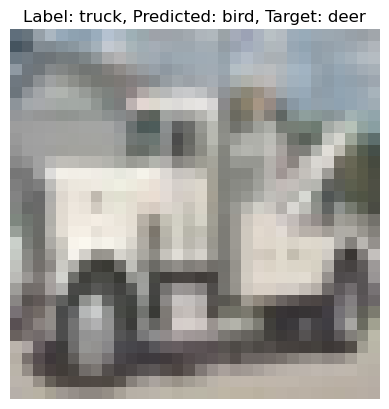

In [8]:
# Select random test point
torch.manual_seed(args.random_seed)
idx = torch.randint(len(test_ds), (1,)).item()
x_star, y_label = test_ds[idx]

with torch.no_grad():
    probs = F.softmax(model(x_star.to(device).unsqueeze(0)), dim=1)[0]
    y_pred = probs.argmax().item()

candidates = [i for i in range(len(test_ds.classes)) if i != y_pred and i != y_label]
y_star = candidates[torch.randint(len(candidates), (1,)).item()]

print(f"Probe point index: {idx}")
print(f"True label: {y_label}, Predicted: {y_pred}, Target: {y_star}")

plt.imshow(x_star.permute(1, 2, 0))
plt.title(f"Label: {test_ds.classes[y_label]}, Predicted: {test_ds.classes[y_pred]}, Target: {test_ds.classes[y_star]}")
plt.axis('off')
plt.show()

In [9]:
# Create a single-example dataset containing only the probe point
# This will be used as the query_dataset for influence computation
from torch.utils.data import Dataset

class ProbeDataset(Dataset):
    """Simple dataset containing a single probe point (x_star, y_star)"""
    def __init__(self, x_star, y_star):
        self.x_star = x_star
        self.y_star = y_star
    
    def __len__(self):
        return 1
    
    def __getitem__(self, idx):
        return self.x_star, self.y_star

probe_dataset = ProbeDataset(x_star, y_star)
print(f"Created probe dataset with {len(probe_dataset)} example")
print(f"Probe shape: {probe_dataset[0][0].shape}, Target class: {probe_dataset[0][1]}")

Created probe dataset with 1 example
Probe shape: torch.Size([3, 32, 32]), Target class: 4


In [10]:
def observable(model, x_star, y_star):
    # Compute log probability
    if x_star.dim() == 1:
        x_star = x_star.unsqueeze(0)
    logits = model(x_star)  # [1, K]
    log_probs = F.log_softmax(logits, dim=-1)
    f = log_probs[0, y_star]  # scalar

    return f

In [11]:
class ClassificationTask(Task):

    def __init__(self):
        super().__init__()

    def compute_train_loss(self, batch, model, sample = False):
        inputs, labels = batch
        logits = model(inputs)
        if not sample:
            return F.cross_entropy(logits, labels, reduction="sum")
        with torch.no_grad():
            probs = torch.nn.functional.softmax(logits.detach(), dim=-1)
            sampled_labels = torch.multinomial(
                probs,
                num_samples=1,
            ).flatten()
        return F.cross_entropy(logits, sampled_labels, reduction="sum")

    
    def compute_measurement(
        self,
        batch,
        model: nn.Module,
    ) -> torch.Tensor:
        inputs, targets = batch

        # Ensure inputs are on the correct device
        if isinstance(inputs, torch.Tensor):
            inputs = inputs.to(model.device if hasattr(model, 'device') else next(model.parameters()).device)
        if isinstance(targets, torch.Tensor):
            targets = targets.to(model.device if hasattr(model, 'device') else next(model.parameters()).device)

        # Remove this line - don't flatten for CNN models!
        # inputs = inputs.view(inputs.size(0), -1)

        # Compute logits and log probabilities
        logits = model(inputs)  # [batch_size, num_classes]
        log_probs = F.log_softmax(logits, dim=-1)  # [batch_size, num_classes]

        # Extract log probability for the target class for each example
        bindex = torch.arange(logits.shape[0]).to(logits.device, non_blocking=False)
        log_probs_target = log_probs[bindex, targets]

        # Return the sum of log probabilities for the batch
        return log_probs_target.sum()


In [12]:
model = model.eval()
task = ClassificationTask()  # No longer needs x_star, y_star parameters
model = prepare_model(model, task)

# Set up the Analyzer class.
analyzer = Analyzer(
    analysis_name="mnist",
    model=model,
    task=task,
)
dataloader_kwargs = DataLoaderKwargs(num_workers=4)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

# Fit all factors.
analyzer.fit_all_factors(
    factors_name="ekfac",
    dataset=train_ds,
    per_device_batch_size=2048,
    overwrite_output_dir=True,
)

# Use the non-augmented version of the training dataset for influence score computations.
eval_train_dataset = train_ds

# Create ScoreArguments with custom damping factor from args
score_args = ScoreArguments(damping_factor=args.damping)
print(f"Using damping factor: {args.damping}")

# Compute pairwise influence scores.
# IMPORTANT: Use probe_dataset (single example) as query_dataset instead of valid_ds
analyzer.compute_pairwise_scores(
    scores_name="ekfac_scores",
    factors_name="ekfac",
    query_dataset=probe_dataset,  # Changed from valid_ds to probe_dataset
    train_dataset=eval_train_dataset,
    per_device_query_batch_size=1,  # Changed from 500 to 1 since we only have 1 query point
    score_args=score_args,  # Pass custom score arguments with damping factor
    overwrite_output_dir=True,
)

/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/covariance.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting covariance matrices [22/22] 100%|██████████ [time left: 00:00, time spent: 00:03]
Performing Eigendecomposition [10/10] 100%|██████████ [time left: 00:00, time spent: 00:00]
/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/eigen.py:398: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting Lambda matrices [22/22] 100%|██████████ [time left: 00:00, time spent: 00:04]


Using damping factor: 0.001


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Computing pairwise scores (training gradient) [11/11] 100%|██████████ [time left: 00:00, time spent: 00:03]
Computing pairwise scores (query gradient) [1/1] 100%|██████████ [time left: 00:00, time spent: 00:03]


In [13]:
scores = analyzer.load_pairwise_scores("ekfac_scores")
print(scores.keys())
print(scores)
print(scores["all_modules"].shape)

dict_keys(['all_modules'])
{'all_modules': tensor([[ 1.8354e+03,  1.4540e+03, -6.9144e-01,  ..., -6.0410e+04,
          4.5765e+04,  8.2286e+02]])}
torch.Size([1, 45000])


In [14]:
scores = analyzer.load_pairwise_scores("ekfac_scores")["all_modules"]
print(f"Scores shape: {scores.shape}")
print(f"Expected shape: (1, {len(train_ds)}) - one query point, all training examples")

# Extract the single row of scores for the probe point
probe_scores = scores[0]  # Shape: (N_train,)
print(f"Probe scores shape: {probe_scores.shape}")

Scores shape: torch.Size([1, 45000])
Expected shape: (1, 45000) - one query point, all training examples
Probe scores shape: torch.Size([45000])


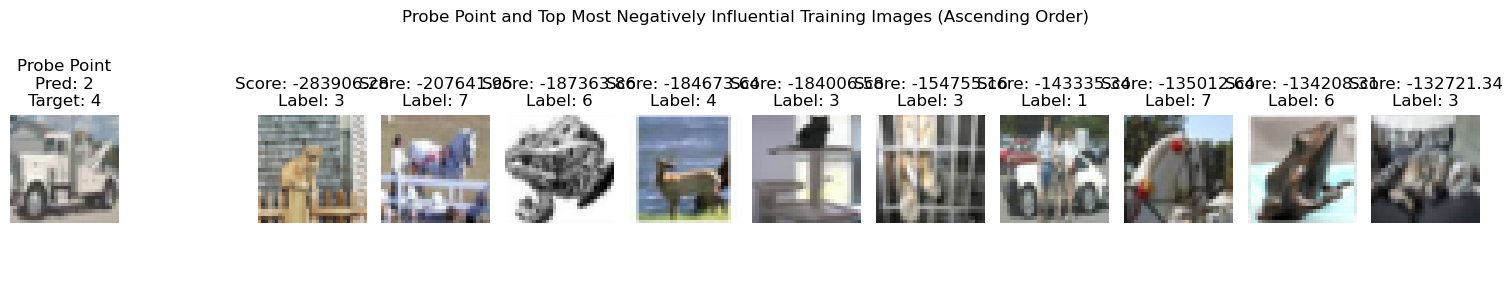


Influence Score Statistics:
  Min: -283906.2812
  Max: 172782.0156
  Mean: 397.5901
  Std: 12222.8359

Top 5 Most Negatively Influential Training Examples:
  1. Index 13154: Label 3, Score -283906.2812
  2. Index 41162: Label 7, Score -207641.9531
  3. Index 39085: Label 6, Score -187363.8594
  4. Index 397: Label 4, Score -184673.6406
  5. Index 21208: Label 3, Score -184006.5781


In [15]:
import numpy as np

def to_display_img(img):
    """
    Converts a tensor or numpy array image of shape (C, H, W) 
    to a valid image shape for matplotlib imshow.
    """
    if isinstance(img, np.ndarray):
        arr = img
    else:
        arr = img.numpy()
    if arr.ndim == 3 and arr.shape[0] in [1, 3]:
        # (C, H, W) -> (H, W, C)
        arr = np.transpose(arr, (1, 2, 0))
        if arr.shape[2] == 1:
            arr = arr[:, :, 0]  # For single channel images, drop the last dimension
    elif arr.ndim == 2:
        pass  # Already (H, W)
    return arr

# Visualize the probe point and its most influential training examples (most negative scores)
n_examp = 10
fig, axs = plt.subplots(ncols=2+n_examp, figsize=(15, 3))
fig.suptitle("Probe Point and Top Most Negatively Influential Training Images (Ascending Order)")

# Show probe point
axs[0].imshow(to_display_img(x_star))
axs[0].axis("off")
axs[0].set_title(f"Probe Point\nPred: {y_pred}\nTarget: {y_star}")
axs[1].axis("off")

# Show top most influential training examples (lowest scores = most negative influence)
top_k_indices = probe_scores.argsort(descending=False)[:args.top_k]
for ii, idx in enumerate(top_k_indices[:n_examp]):
    train_img, train_label = train_ds[idx]
    axs[ii + 2].imshow(to_display_img(train_img))
    axs[ii + 2].axis("off")
    axs[ii + 2].set_title(f"Score: {probe_scores[idx]:.2f}\nLabel: {train_label}")

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nInfluence Score Statistics:")
print(f"  Min: {probe_scores.min():.4f}")
print(f"  Max: {probe_scores.max():.4f}")
print(f"  Mean: {probe_scores.mean():.4f}")
print(f"  Std: {probe_scores.std():.4f}")

print(f"\nTop 5 Most Negatively Influential Training Examples:")
for i, idx in enumerate(top_k_indices[:5]):
    train_img, train_label = train_ds[idx]
    print(f"  {i+1}. Index {idx}: Label {train_label}, Score {probe_scores[idx]:.4f}")

## 7. Compute Optimal Perturbations via PGD

Apply projected gradient descent in input space:

$$z_{t+1} = \text{Proj}_{\|\cdot\|_\infty \leq \epsilon}\left(z_t + \alpha \cdot \text{sign}(G_\delta(z_t))\right)$$

where $G_\delta = -\frac{1}{n}[\nabla_z \nabla_\theta L(z, \theta)]^T v$

In [16]:
[p for p in model.parameters() if p.requires_grad]

[Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True)]

In [17]:
from kronfluence.module.utils import get_tracked_module_names
from kronfluence.module.tracked_module import TrackedModule

def get_tracked_params_and_ihvp(model, enable_grad=True):
    """
    Returns:
        params: list of original_module parameters for all tracked modules in model (ordered)
        v_list: list of IHVPs corresponding to each tracked module (one IHVP per module, not per parameter)
    """
    params = []
    v_list = []
    tracked_module_names = get_tracked_module_names(model)
    print(f"Tracked modules: {tracked_module_names}")

    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            print(f"Module {name} has parameters:")
            ihvp = module.storage["inverse_hessian_vector_product"]

            # Collect all parameters for this module
            for param_name, param in module.original_module.named_parameters():
                print(f"  - {param_name}: {param.shape}")
                if enable_grad:
                    param.requires_grad_(True)
                params.append(param)

            # Add IHVP only once per module (not per parameter)
            v_list.append(ihvp)

    return params, v_list
    

params, v_list = get_tracked_params_and_ihvp(model, enable_grad=True)
print(f"\nNumber of tracked modules: {len(v_list)}")
print(f"Number of parameters: {len(params)}")
for i, v in enumerate(v_list):
    print(f"IHVP {i} shape: {v.shape}")

Tracked modules: ['conv', 'layer1.conv1', 'layer1.conv2', 'layer2.conv1', 'layer2.conv2', 'layer2.downsample.0', 'layer3.conv1', 'layer3.conv2', 'layer3.downsample.0', 'fc']
Module conv has parameters:
  - weight: torch.Size([32, 3, 3, 3])
Module layer1.conv1 has parameters:
  - weight: torch.Size([32, 32, 3, 3])
Module layer1.conv2 has parameters:
  - weight: torch.Size([32, 32, 3, 3])
Module layer2.conv1 has parameters:
  - weight: torch.Size([64, 32, 3, 3])
Module layer2.conv2 has parameters:
  - weight: torch.Size([64, 64, 3, 3])
Module layer2.downsample.0 has parameters:
  - weight: torch.Size([64, 32, 1, 1])
Module layer3.conv1 has parameters:
  - weight: torch.Size([128, 64, 3, 3])
Module layer3.conv2 has parameters:
  - weight: torch.Size([128, 128, 3, 3])
Module layer3.downsample.0 has parameters:
  - weight: torch.Size([128, 64, 1, 1])
Module fc has parameters:
  - weight: torch.Size([10, 128])
  - bias: torch.Size([10])

Number of tracked modules: 10
Number of parameters: 11

In [18]:
"""
Perturbation computation and PGD optimization

Mathematical background:
- G_δ = -(1/n)[∇_z ∇_θ L(z, θ)]^T v, where v = (H + λI)^{-1} ∇_θ f
- δ_opt = argmax_δ {∇_θ f^T Δθ} where Δθ ≈ G_δ^T δ
- PGD: z_{t+1} = Proj_{||·|| ≤ ε}(z_t + α · sign(G_δ))
"""

import torch
import torch.nn.functional as F
from kronfluence.module.utils import get_tracked_module_names
from kronfluence.module.tracked_module import TrackedModule


def get_params(model):
    """Get all parameters from tracked modules"""
    params = []
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            # Collect all parameters for this module
            for param_name, param in module.original_module.named_parameters():
                params.append(param)
    return params


def compute_G_delta(model, X_batch, y_batch, v_list, n_train):
    """
    Compute perturbation gradient G_δ = -(1/n) [∇_x ∇_θ L]^T v

    Uses double-backward to compute cross-Jacobian vector product

    Args:
        model: Trained model
        X_batch: Batch of inputs [B, D]
        y_batch: Batch of labels [B]
        v_list: IHVP vector (list of tensors)
        n_train: Total training set size

    Returns:
        G_delta: Perturbation gradients [B, D]
    """
    params = get_params(model)
    model.eval()

    # Enable gradient w.r.t. inputs
    X_batch = X_batch.detach().requires_grad_(True)

    # Forward pass
    logits = model(X_batch)
    loss = F.cross_entropy(logits, y_batch, reduction='sum')  # sum to keep per-example structure

    # First backward: g = ∇_θ loss
    g_list = torch.autograd.grad(loss, params, create_graph=True)

    # Dot product: s = g^T v (scalar)
    # Combine the weight and bias tensors in g_list to match v_list
    # Assume every two entries in g_list are (weight, bias) for each linear layer
    merged_g_list = []
    i = 0
    while i < len(g_list):
        weight = g_list[i]
        bias = g_list[i + 1]
        # Flatten weight and bias, then concatenate along last dimension
        # Handle 2D weights (e.g., [out, in]) and 1D bias ([out])
        weight_flat = weight.view(weight.size(0), -1)
        bias_flat = bias.view(bias.size(0), 1)
        merged = torch.cat([weight_flat, bias_flat], dim=1)
        merged_g_list.append(merged)
        i += 2
    g_list = merged_g_list


    s = sum((gi * vi).sum() for gi, vi in zip(g_list, v_list))

    # Second backward: ∇_x s = [∇_x ∇_θ L]^T v
    Jt_v = torch.autograd.grad(s, X_batch, retain_graph=False, create_graph=False)[0]

    # Scale and negate
    G_delta = -(1.0 / n_train) * Jt_v

    return G_delta


def apply_pgd_perturbation(model, X_batch, y_batch, v_list, n_train,
                          epsilon=2.0, alpha=0.3, n_steps=20, norm='inf',
                          verbose=False, return_stats=False):
    """
    Apply PGD to find optimal perturbations that maximize observable f(θ)

    z_{t+1} = Proj(z_t + α · sign(G_δ(z_t)))

    Args:
        model: Trained model
        X_batch: Original batch [B, D]
        y_batch: Labels [B]
        v_list: IHVP vector
        n_train: Training set size
        epsilon: L_∞ or L_2 perturbation budget
        alpha: Step size
        n_steps: Number of PGD iterations
        norm: 'inf' or '2'
        verbose: Print convergence diagnostics
        return_stats: If True, return (X_perturbed, norms, stats_dict)

    Returns:
        X_perturbed: Perturbed batch [B, D]
        perturbation_norms: Norms of final perturbations [B]
        stats (optional): Dictionary with gradient and perturbation histories
    """
    X_orig = X_batch.clone()
    X_adv = X_batch.clone()
    B = X_batch.size(0)

    def project_linf(x0, x_cand, eps):
        return torch.clamp(x_cand, x0 - eps, x0 + eps)

    def project_l2(x0, x_cand, eps):
        delta = x_cand - x0
        norms = torch.norm(delta.reshape(B, -1), p=2, dim=1, keepdim=True)
        scale = torch.clamp(eps / (norms + 1e-12), max=1.0)
        return x0 + delta * scale.reshape(-1, *([1] * (delta.ndim - 1)))

    # Always track convergence for return_stats
    grad_norms = []
    pert_norms_history = []

    # PGD iterations
    for step in range(n_steps):
        # Compute gradient direction
        G_delta = compute_G_delta(model, X_adv, y_batch, v_list, n_train)

        # Track metrics
        gnorm = G_delta.abs().mean().item()
        grad_norms.append(gnorm)

        current_delta = X_adv - X_orig
        if norm == 'inf':
            pnorm = torch.norm(current_delta.reshape(B, -1), p=float('inf'), dim=1).mean().item()
        else:
            pnorm = torch.norm(current_delta.reshape(B, -1), p=2, dim=1).mean().item()
        pert_norms_history.append(pnorm)

        if verbose and (step % 10 == 0 or step == n_steps - 1):
            print(f"  Step {step:3d}: ||G_δ|| = {gnorm:.6f}, ||δ|| = {pnorm:.6f}")

        # Take step
        if norm == 'inf':
            step_vec = alpha * torch.sign(G_delta)
            X_cand = X_adv + step_vec
            X_adv = project_linf(X_orig, X_cand, epsilon)
        elif norm == '2':
            g_norms = torch.norm(G_delta.reshape(B, -1), p=2, dim=1, keepdim=True) + 1e-12
            step_vec = alpha * (G_delta / g_norms.reshape(-1, 1))
            X_cand = X_adv + step_vec
            X_adv = project_l2(X_orig, X_cand, epsilon)
        else:
            raise ValueError(f"Unknown norm: {norm}")

    # Compute final perturbation norms
    delta = X_adv - X_orig
    if norm == 'inf':
        pert_norms = torch.norm(delta.reshape(B, -1), p=float('inf'), dim=1)
    else:
        pert_norms = torch.norm(delta.reshape(B, -1), p=2, dim=1)

    # Print convergence analysis
    if verbose:
        print(f"\nConvergence Analysis:")
        print(f"  Initial gradient norm: {grad_norms[0]:.6f}")
        print(f"  Final gradient norm: {grad_norms[-1]:.6f}")
        print(f"  Gradient reduction: {grad_norms[-1]/grad_norms[0]:.2e}")
        print(f"  Final perturbation norm: {pert_norms_history[-1]:.6f}")
        print(f"  Epsilon budget: {epsilon:.6f}")
        if pert_norms_history[-1] < epsilon * 0.9:
            print(f"  → PGD CONVERGED before hitting epsilon constraint")
        else:
            print(f"  → Hit epsilon constraint")

    if return_stats:
        stats = {
            'initial_grad_norm': grad_norms[0],
            'final_grad_norm': grad_norms[-1],
            'gradient_reduction': grad_norms[-1] / (grad_norms[0] + 1e-12),
            'grad_history': grad_norms,
            'pert_norms_history': pert_norms_history,
            'converged': pert_norms_history[-1] < epsilon * 0.9
        }
        return X_adv, pert_norms, stats

    return X_adv, pert_norms

In [19]:
print(f"Applying PGD perturbation...")
print(f"  ε = {args.epsilon} (L_∞ budget)")
print(f"  α = {args.alpha} (step size)")
print(f"  Steps = {args.n_steps}\n")


# Get selected batch for Subset-wrapped MNIST, which has no .tensors attribute
orig_dataset = train_ds.dataset if hasattr(train_ds, 'dataset') else train_ds
orig_indices = train_ds.indices if hasattr(train_ds, 'indices') else range(len(train_ds))
selected_indices = [orig_indices[i] for i in top_k_indices]

# MNIST indexing returns (image, label) tuples; use a list comprehension and stack
imgs, labels = zip(*(orig_dataset[i] for i in selected_indices))
X_selected = torch.stack(imgs).to(device)
y_selected = torch.tensor(labels).to(device)
n_train = len(train_ds)


# Apply PGD with convergence monitoring
X_perturbed, pert_norms = apply_pgd_perturbation(
    model, X_selected, y_selected, v_list, len(train_ds),
    epsilon=args.epsilon,
    alpha=args.alpha,
    n_steps=args.n_steps,
    norm='inf',
    verbose=True  # Show convergence diagnostics
)

print(f"\nPerturbation applied!")
print(f"  Mean L_∞ norm: {pert_norms.mean():.4f}")
print(f"  Max L_∞ norm: {pert_norms.max():.4f}")

Applying PGD perturbation...
  ε = 0.5 (L_∞ budget)
  α = 0.001 (step size)
  Steps = 20



RuntimeError: shape '[32, 1]' is invalid for input of size 9216

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.050588243..1.0160007].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12000024..0.12000167].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0017647037..1.000392].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12000024..0.12000024].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.016078433..1.0200009].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12000024..0.12000561].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.011372548..1.0200009].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12000024..0.12000561].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12000024..0.12000024].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12000024..0.12000024].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0043137274..0.9650978].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got rang

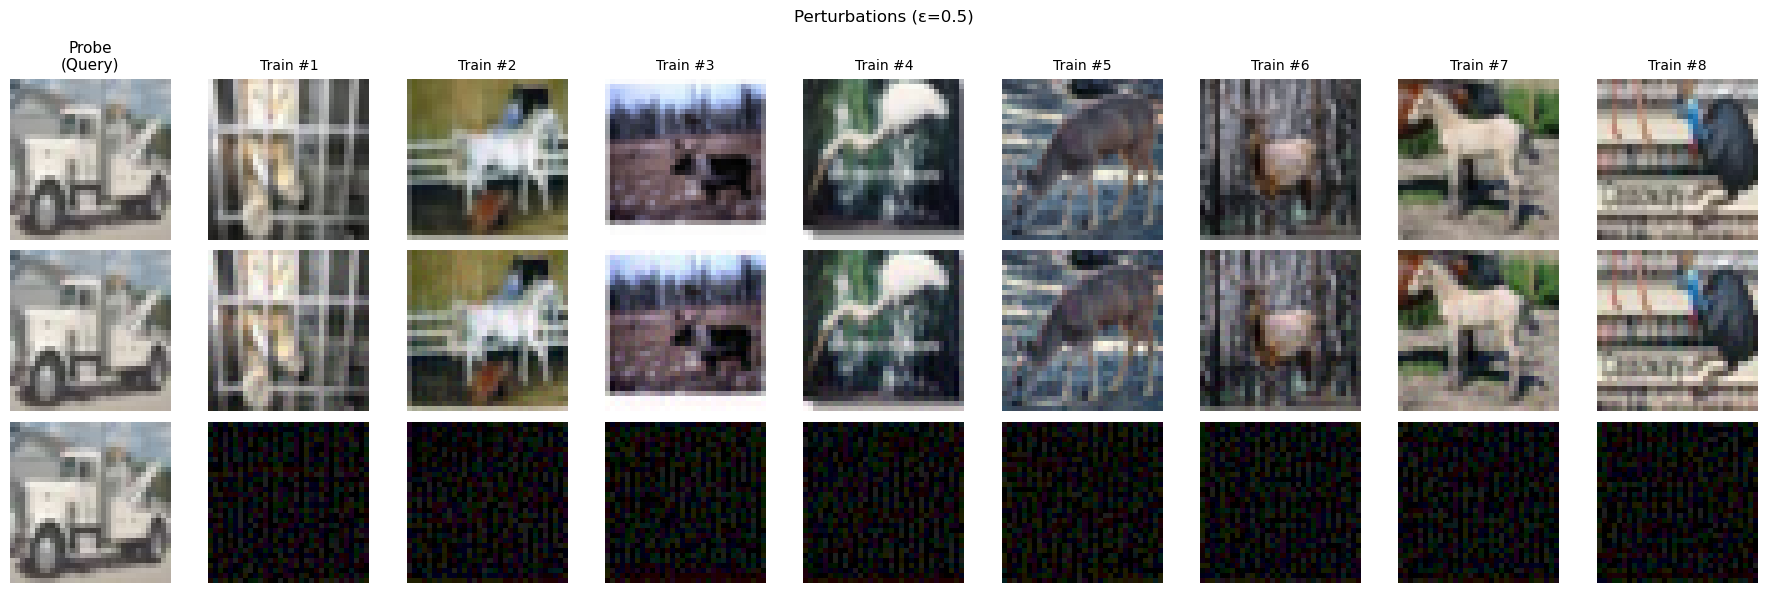

In [ ]:
# Visualize perturbations (works for MNIST and CIFAR10)
# Add probe image on the far left
n_show = min(8, X_selected.shape[0])

# Subplot layout: 3 rows (Original, Perturbed, Δ), n_show + 1 columns (probe + n_show samples)
fig, axes = plt.subplots(3, n_show + 1, figsize=(2*(n_show + 1), 6))

# Infer image shape and cmap for training images (used for all visualizations)
img_shape = X_selected.shape[1:]  # (C, H, W) or (H, W)
is_grayscale = (len(img_shape) == 2) or (img_shape[0] == 1)
cmap = 'gray' if is_grayscale else None

def prep_image(x):
    x = x.detach().cpu()
    if len(x.shape) == 3 and x.shape[0] == 1:
        # (1, H, W) -> (H, W)
        return x[0]
    if len(x.shape) == 3 and x.shape[0] == 3:
        # (3, H, W) -> (H, W, 3)
        return x.permute(1, 2, 0)
    if len(x.shape) == 2:
        return x
    raise ValueError(f'Unexpected image shape: {x.shape}')

# Plot the probe image on the far left (column 0)
if 'x_star' in locals():
    probe_img = prep_image(x_star)
    for row in range(3):
        axes[row, 0].imshow(probe_img, cmap=cmap)
        axes[row, 0].axis('off')
    axes[0, 0].set_ylabel('Probe', fontsize=10)
    axes[0, 0].set_title('Probe\n(Query)', fontsize=10)
else:
    for row in range(3):
        axes[row, 0].axis('off')
    axes[0, 0].set_ylabel('Probe', fontsize=10)
    axes[0, 0].set_title('Probe\n(Query)', fontsize=10)

# Plot each of the selected training images and their perturbation/difference
for i in range(n_show):
    col = i + 1  # offset by 1 because col 0 is the probe image

    # Original
    axes[0, col].imshow(prep_image(X_selected[i]), cmap=cmap)
    axes[0, col].axis('off')
    if col == 1:  # first training example
        axes[0, col].set_ylabel('Original', fontsize=10)

    # Perturbed
    axes[1, col].imshow(prep_image(X_perturbed[i]), cmap=cmap)
    axes[1, col].axis('off')
    if col == 1:
        axes[1, col].set_ylabel('Perturbed', fontsize=10)

    # Difference (amplified for visibility)
    diff = (X_perturbed[i] - X_selected[i]).detach().cpu()
    if len(diff.shape) == 3 and diff.shape[0] == 1:
        diff_to_show = diff[0]
    elif len(diff.shape) == 3 and diff.shape[0] == 3:
        diff_to_show = diff.permute(1, 2, 0)
    else:
        diff_to_show = diff

    # Increase the visibility of the difference image by amplifying the values for display (clipped for stability).
    diff_vis = diff_to_show / args.epsilon  # Normalize to -1...1
    diff_vis = torch.clamp(diff_vis, -1.0, 1.0)
    # Enhance contrast further if needed:
    contrast_factor = 3.0  # Increase if you want it to pop more
    diff_vis_enhanced = diff_vis * contrast_factor
    diff_vis_enhanced = torch.clamp(diff_vis_enhanced, -1.0, 1.0)
    axes[2, col].imshow(diff_vis_enhanced, cmap='bwr', vmin=-1, vmax=1)
    axes[2, col].axis('off')
    if col == 1:
        axes[2, col].set_ylabel('Δ (difference)', fontsize=10)

# Titles for each column
axes[0, 0].set_title('Probe\n(Query)', fontsize=11)
for i in range(n_show):
    axes[0, i + 1].set_title(f"Train #{i+1}", fontsize=10)

plt.suptitle(f'Perturbations (ε={args.epsilon})', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Retrain Model on Perturbed Dataset

Replace selected training points with perturbed versions and retrain from scratch.

**Important:** We retrain to verify that the perturbations actually increase the target probability.

In [ ]:
# Create modified training dataset with perturbations
from torch.utils.data import TensorDataset, Subset

# Get the original full dataset and indices
orig_dataset = train_ds.dataset if hasattr(train_ds, 'dataset') else train_ds
orig_indices = train_ds.indices if hasattr(train_ds, 'indices') else range(len(train_ds))

# Convert to lists of images and labels - keep everything on CPU for dataset
all_imgs = []
all_labels = []
for i in orig_indices:
    img, label = orig_dataset[i]
    all_imgs.append(img)
    all_labels.append(label)

X_train_tensor = torch.stack(all_imgs)  # This will be on CPU
y_train_tensor = torch.tensor(all_labels)  # This will be on CPU

# Create modified dataset - move X_perturbed to CPU for dataset storage
X_modified = X_train_tensor.clone()

# Convert top_k_indices to a CPU tensor for indexing
if torch.is_tensor(top_k_indices):
    top_k_indices_cpu = top_k_indices.cpu().long()
else:
    top_k_indices_cpu = torch.tensor(top_k_indices, device='cpu', dtype=torch.long)

# Move perturbed images to CPU and ensure same dtype as X_train_tensor
X_perturbed_cpu = X_perturbed.cpu().to(dtype=X_train_tensor.dtype)

# Replace the selected indices with perturbed versions
X_modified[top_k_indices_cpu] = X_perturbed_cpu

print(f"Created modified dataset:")
print(f"  Original training size: {len(X_train_tensor)}")
print(f"  Number of perturbed examples: {len(top_k_indices)}")
print(f"  Perturbation epsilon: {args.epsilon}")
print(f"  Mean perturbation norm: {pert_norms.mean():.4f}")
print(f"  Dataset device: {X_modified.device} (will be moved to {device} by dataloader)")

# Create new dataset (on CPU - dataloader will move to device during training)
modified_dataset = TensorDataset(X_modified, y_train_tensor)

Created modified dataset:
  Original training size: 45000
  Number of perturbed examples: 32
  Perturbation epsilon: 0.5
  Mean perturbation norm: 0.0200
  Dataset device: cpu (will be moved to cuda by dataloader)


Retraining model on modified dataset...



Training for 40 epochs...:   0%|          | 0/40 [00:00<?, ?it/s]

Training for 40 epochs...:   2%|▎         | 1/40 [00:00<00:38,  1.02it/s]

0 1.7655035995059543 1.5752779418945313


Training for 40 epochs...:   5%|▌         | 2/40 [00:01<00:35,  1.07it/s]

...

37 0.32243029742770724 5.109364213562012


Training for 40 epochs...:  98%|█████████▊| 39/40 [00:37<00:01,  1.04s/it]

38 0.30312751467492843 5.712832238006592


Training for 40 epochs...: 100%|██████████| 40/40 [00:38<00:00,  1.05it/s]

39 0.2860731223848131 5.463019051361084


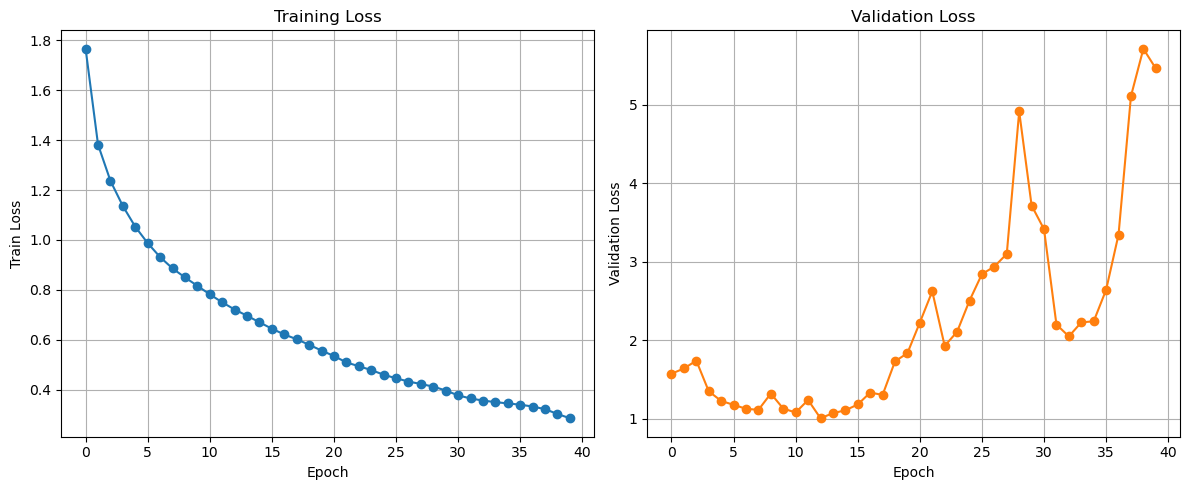


Retrained model training complete!


In [ ]:
# Retrain model on modified dataset
print(f"Retraining model on modified dataset...\n")

# Create dataloader for modified dataset
modified_dl = get_dataloader(modified_dataset, args.batch_size)

# Completely reinitialize the model for retraining
model_retrained = make_model().to(device)


# Use same optimizer and loss function
opt_retrained = torch.optim.SGD(model_retrained.parameters(), lr=args.learning_rate, momentum=args.momentum, weight_decay=args.weight_decay)
loss_func_retrained = torch.nn.CrossEntropyLoss()

# Train using the same function
ckpt_dir_retrained = "./checkpoints/retrained/"
if not os.path.exists(ckpt_dir_retrained):
    os.makedirs(ckpt_dir_retrained, exist_ok=True)

fit(args.epochs, model_retrained, loss_func_retrained, opt_retrained, modified_dl, valid_dl, ckpt_dir_retrained)

print(f"\nRetrained model training complete!")

In [ ]:
# Evaluate test accuracy BEFORE and AFTER perturbation
print("=" * 70)
print("TEST SET PERFORMANCE COMPARISON")
print("=" * 70)

# Original model test accuracy
correct_before = 0
total_before = 0
with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        y = y.to(device)
        outputs = model(x)
        predicted = outputs.argmax(dim=-1)
        correct_before += (predicted == y).sum().item()
        total_before += y.size(0)

test_acc_before = correct_before / total_before

# Retrained model test accuracy
correct_after = 0
total_after = 0
with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        y = y.to(device)
        outputs = model_retrained(x)
        predicted = outputs.argmax(dim=-1)
        correct_after += (predicted == y).sum().item()
        total_after += y.size(0)

test_acc_after = correct_after / total_after

# Compare
delta_test_acc = test_acc_after - test_acc_before

print(f"\nTest Accuracy BEFORE perturbation: {test_acc_before*100:.2f}%")
print(f"Test Accuracy AFTER perturbation:  {test_acc_after*100:.2f}%")
print(f"\nChange in test accuracy: {delta_test_acc*100:+.2f}%")

if abs(delta_test_acc) < 0.01:
    print("✓ Test accuracy MAINTAINED (within 1%)")
elif delta_test_acc > 0:
    print(f"✓ Test accuracy IMPROVED by {delta_test_acc*100:.2f}%")
else:
    print(f"⚠ Test accuracy DEGRADED by {abs(delta_test_acc)*100:.2f}%")

print("=" * 70)

TEST SET PERFORMANCE COMPARISON



Test Accuracy BEFORE perturbation: 65.46%
Test Accuracy AFTER perturbation:  27.20%

Change in test accuracy: -38.26%
⚠ Test accuracy DEGRADED by 38.26%


In [ ]:
# Compute G_delta for the selected points to predict observable change
G_delta = compute_G_delta(model, X_selected, y_selected, v_list, len(train_ds))

# Compute actual perturbations
delta = X_perturbed - X_selected

# Predicted change in observable: Δf ≈ G_δ^T δ
predicted_delta_f = (G_delta * delta).sum().item()

print(f"Predicted change in observable (from theory):")
print(f"  Δf ≈ G_δ^T δ = {predicted_delta_f:.6f}")
print(f"\nIf predicted Δf > 0, theory expects probability to INCREASE")
print(f"If predicted Δf < 0, theory expects probability to DECREASE")
print(f"\nPrediction: Observable will {'INCREASE ✓' if predicted_delta_f > 0 else 'DECREASE ✗'}")

Predicted change in observable (from theory):
  Δf ≈ G_δ^T δ = 40.043556

If predicted Δf > 0, theory expects probability to INCREASE
If predicted Δf < 0, theory expects probability to DECREASE

Prediction: Observable will INCREASE ✓


## 9. Verify Observable Increase ✓

**Main Result:** Did we successfully increase $p(y^*|x^*; \theta)$?

In [ ]:
# Get probe probabilities BEFORE and AFTER
with torch.no_grad():
    # Original model
    logits_before = model(x_star.unsqueeze(0).to(device))
    probs_before = F.softmax(logits_before, dim=1)[0]
    prob_target_before = probs_before[y_star].item()
    pred_before = torch.argmax(probs_before).item()
    
    # Retrained model
    logits_after = model_retrained(x_star.unsqueeze(0).to(device))
    probs_after = F.softmax(logits_after, dim=1)[0]
    prob_target_after = probs_after[y_star].item()
    pred_after = torch.argmax(probs_after).item()

# Get true label of probe point
true_label = y_label

delta_prob = prob_target_after - prob_target_before

# Display results
print("=" * 70)
print("OBSERVABLE CHANGE: f(θ) = log p(y*|x*; θ)")
print("=" * 70)
print(f"\nProbe point: test index {idx}")
print(f"True label: {true_label}")
print(f"Predicted class BEFORE: {pred_before}")
print(f"Predicted class AFTER: {pred_after}")
print(f"Target class: y* = {y_star}")
print(f"\nBEFORE perturbation:")
print(f"  Probabilities: {probs_before.cpu().numpy()}")
print(f"  p(y*={y_star}|x*) = {prob_target_before:.6f}")
print(f"\nAFTER perturbation & retrain:")
print(f"  Probabilities: {probs_after.cpu().numpy()}")
print(f"  p(y*={y_star}|x*) = {prob_target_after:.6f}")
print(f"\n{'='*70}")
print(f"RESULT: Δp = {delta_prob:+.6f} ({delta_prob*100:+.4f}%)")
if delta_prob > 0:
    print(f"✓ SUCCESS: Observable INCREASED by {delta_prob*100:.4f}%")
else:
    print(f"✗ Observable decreased by {abs(delta_prob)*100:.4f}%")
print("=" * 70)

OBSERVABLE CHANGE: f(θ) = log p(y*|x*; θ)

Probe point: test index 21445
True label: 9
Predicted class BEFORE: 9
Predicted class AFTER: 5
Target class: y* = 4

BEFORE perturbation:
  Probabilities: [0.01584988 0.07641245 0.00133471 0.01048627 0.01381804 0.00474502
 0.00107925 0.03748785 0.02255819 0.8162283 ]
  p(y*=4|x*) = 0.013818

AFTER perturbation & retrain:
  Probabilities: [1.3628275e-05 7.4565020e-07 6.5194996e-09 4.6343476e-02 5.2474047e-07
 9.5357037e-01 4.9943796e-11 4.3090745e-06 4.3359019e-10 6.6901011e-05]
  p(y*=4|x*) = 0.000001

RESULT: Δp = -0.013818 (-1.3818%)
✗ Observable decreased by 1.3818%


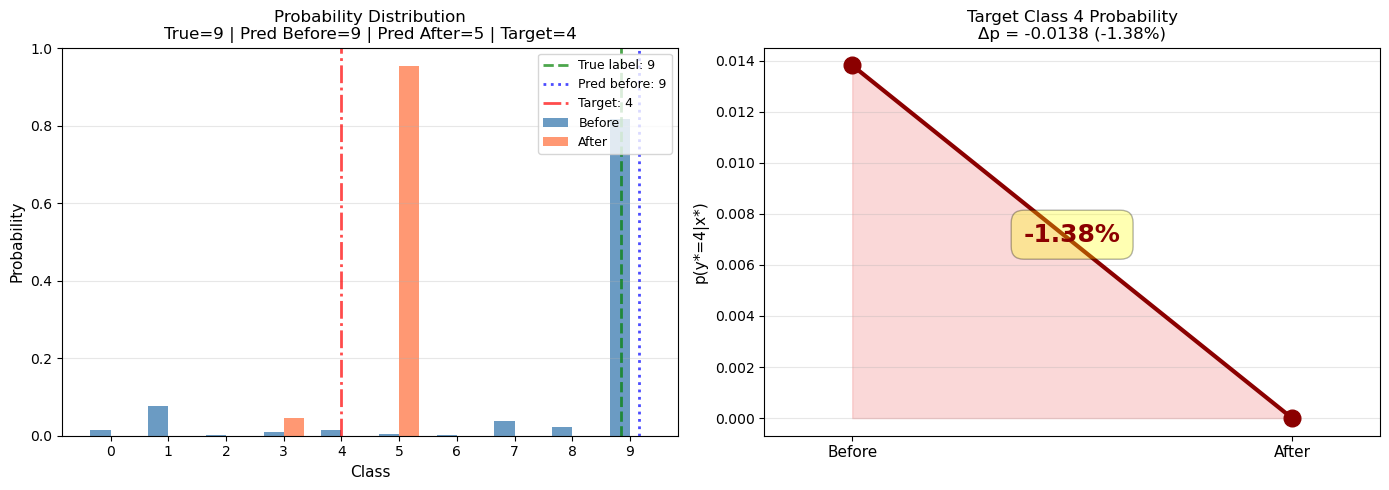

In [ ]:
# Visualize probability change
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
n_classes = num_classes
x_pos = np.arange(n_classes)
width = 0.35

ax1.bar(x_pos - width/2, probs_before.cpu().numpy(), width, label='Before', alpha=0.8, color='steelblue')
ax1.bar(x_pos + width/2, probs_after.cpu().numpy(), width, label='After', alpha=0.8, color='coral')

# Mark important classes with vertical lines
ax1.axvline(true_label - 0.15, color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'True label: {true_label}')
ax1.axvline(pred_before + 0.15, color='blue', linestyle=':', alpha=0.7, linewidth=2, label=f'Pred before: {pred_before}')
ax1.axvline(y_star, color='red', linestyle='-.', alpha=0.7, linewidth=2, label=f'Target: {y_star}')

ax1.set_xlabel('Class', fontsize=11)
ax1.set_ylabel('Probability', fontsize=11)
ax1.set_title(f'Probability Distribution\nTrue={true_label} | Pred Before={pred_before} | Pred After={pred_after} | Target={y_star}', 
              fontsize=12)
ax1.set_xticks(x_pos)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# Target class probability change
ax2.plot([0, 1], [prob_target_before, prob_target_after], 'o-', 
         markersize=12, linewidth=3, color='darkred')
ax2.fill_between([0, 1], [prob_target_before, prob_target_after], alpha=0.3, color='lightcoral')
ax2.set_xlim(-0.2, 1.2)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Before', 'After'], fontsize=11)
ax2.set_ylabel(f'p(y*={y_star}|x*)', fontsize=11)
ax2.set_title(f'Target Class {y_star} Probability\nΔp = {delta_prob:+.4f} ({delta_prob*100:+.2f}%)', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

# Add text annotation
ax2.annotate(f'{delta_prob*100:+.2f}%', 
             xy=(0.5, (prob_target_before + prob_target_after)/2),
             fontsize=18, ha='center', color='darkred', weight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.show()